# Tell-Whisper Pipeline Evaluation on ViMD.fix Val Set

**Goal:** Đánh giá full pipeline (WavLM + MASR + PhoWhisper-Large) trên toàn bộ validation set.

**Pipeline:**
```
ViMD.fix Val → VAD → WavLM Sliding Window → Spectral Clustering
    → MASR Verification (15%) → Cross-Reference (85/15)
    → PhoWhisper-Large ASR → Metrics (WER, CER, DER)
```

**Metrics:**
| Metric | Ý nghĩa |
|---|---|
| **WER** | Tỷ lệ lỗi từ (Word Error Rate) — ASR quality |
| **CER** | Tỷ lệ lỗi ký tự (Character Error Rate) |
| **DER** | Tỷ lệ lỗi diarization (Diarization Error Rate) |
| **MASR Agreement** | % segments MASR đồng ý với WavLM |


In [ ]:
# Cell 1: Setup
!pip install -q transformers accelerate soundfile librosa jiwer scikit-learn

import os, sys, json, glob, zipfile, time, string
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import soundfile as sf
import librosa
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from jiwer import wer as compute_wer, cer as compute_cer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import SpectralClustering
from scipy.signal import medfilt
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 12

from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [ ]:
# Cell 2: Config
class Config:
    # Models
    DIAR_MODEL_BASE = 'vinai/PhoWhisper-small'
    DIAR_CHECKPOINT = '/content/drive/MyDrive/Method/best_model.pt'
    ASR_MODEL_NAME = 'vinai/PhoWhisper-large'
    MAX_SPEAKERS = 4
    NUM_SPEAKERS_EXPECTED = 2

    # Data
    DATASET_ZIP = '/content/drive/MyDrive/Method/'
    EXTRACT_DIR = '/content/drive/MyDrive/training_data'

    # Eval
    NUM_SAMPLES = None  # None = ALL validation samples, or set e.g. 50

    # VAD
    VAD_ENERGY_THRESHOLD = 0.008
    VAD_MIN_SPEECH_SEC = 0.3
    VAD_MIN_SILENCE_SEC = 0.3

    # Diarization (WavLM)
    SAMPLE_RATE = 16000
    DIAR_WINDOW_SEC = 1.5
    DIAR_STEP_SEC = 0.5
    DIAR_BATCH_SIZE = 16
    DIAR_SMOOTH_KERNEL = 5
    DIAR_MIN_SEGMENT_SEC = 1.0

    # Cross-Reference
    MASR_WEIGHT = 0.15
    WAVLM_WEIGHT = 0.85

    # Merge
    MERGE_GAP_SEC = 1.0

    OUTPUT_DIR = '/content/drive/MyDrive/eval_results'

cfg = Config()
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
print("Config ready!")


Config ready!


---
## 1. Load Models

Load 3 models: WavLM (speaker embedding), MASR (diarization tham khảo), PhoWhisper-Large (ASR).


In [ ]:
# Cell 3: Model Definitions
class TSPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * -(np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)
    def forward(self, x):
        return x + self.pe[:x.size(1)]

class HyperSDModule(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, num_speakers=4, num_classes=5):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.LayerNorm(hidden_dim),
            nn.GELU(), nn.Dropout(0.1)
        )
        self.speaker_head = nn.Linear(hidden_dim, num_speakers)
        self.class_head = nn.Linear(hidden_dim, num_classes)
    def forward(self, h):
        h = self.proj(h)
        return self.speaker_head(h), self.class_head(h)

class MASR(nn.Module):
    def __init__(self, phowhisper, hidden_dim=256, num_speakers=4):
        super().__init__()
        self.phowhisper = phowhisper
        self.encoder_dim = phowhisper.config.d_model
        self.ts_pos = TSPositionalEncoding(self.encoder_dim)
        self.hyper_sd = HyperSDModule(self.encoder_dim, hidden_dim, num_speakers)

    def forward_diarization(self, feats):
        with torch.no_grad():
            enc = self.phowhisper.model.encoder(feats)
            h = self.ts_pos(enc.last_hidden_state)
            spk_logits, cls_logits = self.hyper_sd(h)
            return torch.sigmoid(spk_logits), cls_logits

print("Model definitions ready")


Model definitions ready


In [ ]:
# Cell 4: Load Models
# 1. MASR
print("Loading MASR...")
proc_diar = WhisperProcessor.from_pretrained(cfg.DIAR_MODEL_BASE)
model_base = WhisperForConditionalGeneration.from_pretrained(cfg.DIAR_MODEL_BASE)
special_tokens = [f'<|spk{i}|>' for i in range(1, cfg.MAX_SPEAKERS+1)]
proc_diar.tokenizer.add_tokens(special_tokens)
model_base.resize_token_embeddings(len(proc_diar.tokenizer))
masr = MASR(model_base, 256, cfg.MAX_SPEAKERS).to(device)
masr_available = False
if os.path.exists(cfg.DIAR_CHECKPOINT):
    ckpt = torch.load(cfg.DIAR_CHECKPOINT, map_location=device, weights_only=False)
    sd = ckpt.get('model', ckpt.get('model_state_dict', ckpt))
    masr.load_state_dict(sd, strict=False)
    masr_available = True
    print("  ✓ MASR loaded!")
else:
    print(f"  ⚠ Checkpoint not found: {cfg.DIAR_CHECKPOINT}")
masr.eval()

# 2. WavLM
print("Loading WavLM Speaker Encoder...")
from transformers import Wav2Vec2FeatureExtractor, WavLMForXVector
wavlm_feat = Wav2Vec2FeatureExtractor.from_pretrained('microsoft/wavlm-base-plus-sv')
wavlm_model = WavLMForXVector.from_pretrained('microsoft/wavlm-base-plus-sv').to(device)
wavlm_model.eval()
print("  ✓ WavLM loaded!")

# 3. PhoWhisper-Large
print(f"Loading {cfg.ASR_MODEL_NAME} (FP16)...")
proc_asr = WhisperProcessor.from_pretrained(cfg.ASR_MODEL_NAME)
model_asr = WhisperForConditionalGeneration.from_pretrained(
    cfg.ASR_MODEL_NAME, torch_dtype=torch.float16
).to(device)
model_asr.eval()
print("  ✓ PhoWhisper-Large loaded!")

print(f"\n✓ All 3 models ready! (MASR: {'✓' if masr_available else '✗'})")


Loading MASR...


Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 657, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '403 Forbidden' for url 'https://huggingface.co/api/models/vinai/PhoWhisper-small/discussions?p=0'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.p

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to proj_out.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  ✓ MASR loaded!
Loading WavLM Speaker Encoder...


...

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 657, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '403 Forbidden' for url 'https://huggingface.co/api/models/vinai/PhoWhisper-large/discussions?p=0'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.p

Loading weights:   0%|          | 0/1260 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to proj_out.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json: 0.00B [00:00, ?B/s]

  ✓ PhoWhisper-Large loaded!

✓ All 3 models ready! (MASR: ✓)


---
## 2. Load ViMD.fix Validation Set


In [ ]:
with open(f"{cfg.EXTRACT_DIR}/metadata.json", "r", encoding="utf-8") as f:
    all_metadata = json.load(f)

# Same split as training
_, val_meta = train_test_split(all_metadata, test_size=0.1, random_state=42)
print(f"Total Val Samples: {len(val_meta)}")

if cfg.NUM_SAMPLES:
    val_meta = val_meta[:cfg.NUM_SAMPLES]
    print(f"Subset: {len(val_meta)} samples")

# Quick stats
has_overlap = sum(1 for m in val_meta if m.get('has_overlap', False))
print(f"  With overlap: {has_overlap}/{len(val_meta)}")
print(f"  Single speaker: {len(val_meta) - has_overlap}/{len(val_meta)}")


Total Val Samples: 1503
  With overlap: 769/1503
  Single speaker: 734/1503


---
## 3. Full Pipeline Function

Chạy toàn bộ pipeline trên 1 sample: VAD → WavLM → Clustering → MASR Verify → Cross-Ref → ASR.


In [ ]:
# Cell 6: Utility Functions
def normalize_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return " ".join(text.split())

def energy_vad(audio, sr, threshold=0.01, min_speech=0.3, min_silence=0.3):
    frame_len = int(sr * 0.03)
    hop = frame_len // 2
    n_frames = max(1, (len(audio) - frame_len) // hop + 1)

    energy = np.array([
        np.sum(audio[i*hop:i*hop+frame_len]**2) / frame_len
        for i in range(n_frames)
    ])
    if energy.max() > 0:
        energy /= energy.max()

    is_speech = energy > threshold

    min_sil_f = int(min_silence * 1000 / 30)
    i = 0
    while i < len(is_speech):
        if not is_speech[i]:
            j = i
            while j < len(is_speech) and not is_speech[j]: j += 1
            if j - i < min_sil_f and i > 0 and j < len(is_speech):
                is_speech[i:j] = True
            i = j
        else:
            i += 1

    segs = []
    in_s = False; start = 0
    for i in range(len(is_speech)):
        if is_speech[i] and not in_s: start = i; in_s = True
        elif not is_speech[i] and in_s:
            s_sec = max(0, start * hop / sr - 0.15)
            e_sec = min(len(audio)/sr, i * hop / sr + 0.15)
            if e_sec - s_sec >= min_speech:
                segs.append((s_sec, e_sec))
            in_s = False
    if in_s:
        s_sec = max(0, start * hop / sr - 0.15)
        e_sec = len(audio) / sr
        if e_sec - s_sec >= min_speech:
            segs.append((s_sec, e_sec))

    return segs if segs else [(0, len(audio)/sr)]

print("Utility functions ready")


Utility functions ready


In [ ]:
# Cell 7: Full Pipeline Function

def run_pipeline(audio, sr):
    # Run full pipeline on a single audio sample.
    # Returns: predictions list, speaker_segments, cross_ref_sources
    duration = len(audio) / sr

    # 1. VAD
    vad_segments = energy_vad(
        audio, sr,
        threshold=cfg.VAD_ENERGY_THRESHOLD,
        min_speech=cfg.VAD_MIN_SPEECH_SEC,
        min_silence=cfg.VAD_MIN_SILENCE_SEC
    )

    # 2. WavLM Sliding Window (VAD-integrated)
    DIAR_WINDOW = cfg.DIAR_WINDOW_SEC
    DIAR_STEP = cfg.DIAR_STEP_SEC

    windows_audio = []
    window_times = []
    for vad_start, vad_end in vad_segments:
        pos = vad_start
        while pos + DIAR_WINDOW <= vad_end + 0.3:
            win_end = min(pos + DIAR_WINDOW, vad_end)
            win = audio[int(pos*sr):int(win_end*sr)]
            if len(win) >= int(0.5 * sr):
                windows_audio.append(win)
                window_times.append((pos, win_end))
            pos += DIAR_STEP

    if len(windows_audio) < 2:
        # Too short — single speaker fallback
        text = ""
        if len(audio) > int(0.3 * sr):
            input_vals = proc_asr(audio, sampling_rate=sr, return_tensors="pt").input_features.to(device).half()
            with torch.no_grad():
                gen_ids = model_asr.generate(input_vals, max_new_tokens=256, language='vi')
            text = proc_asr.batch_decode(gen_ids, skip_special_tokens=True)[0].strip()
        return [{'start': 0, 'end': duration, 'speaker': 'Speaker 1', 'text': text}], [], Counter()

    # 3. Batch WavLM Embeddings
    all_embs = []
    for i in range(0, len(windows_audio), cfg.DIAR_BATCH_SIZE):
        batch = windows_audio[i:i+cfg.DIAR_BATCH_SIZE]
        inputs = wavlm_feat(batch, sampling_rate=sr, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = wavlm_model(**inputs)
            embs = out.embeddings.cpu().numpy()
        all_embs.append(embs)
    all_embs = np.concatenate(all_embs, axis=0)

    # 4. StandardScaler + Spectral Clustering
    scaler = StandardScaler()
    embs_scaled = scaler.fit_transform(all_embs)
    embs_final = normalize(embs_scaled, norm='l2')

    n_neighbors = min(15, len(embs_final)-1)
    clustering = SpectralClustering(
        n_clusters=cfg.NUM_SPEAKERS_EXPECTED,
        affinity='nearest_neighbors',
        n_neighbors=max(2, n_neighbors),
        assign_labels='discretize',
        random_state=42
    )
    window_labels = clustering.fit_predict(embs_final)
    k = min(cfg.DIAR_SMOOTH_KERNEL, len(window_labels))
    if k % 2 == 0: k -= 1
    k = max(1, k)
    window_labels_smooth = medfilt(window_labels, kernel_size=k).astype(int)

    # 5. Convert to speaker segments
    speaker_segments = []
    current_spk = window_labels_smooth[0]
    current_start = window_times[0][0]

    for i in range(1, len(window_labels_smooth)):
        if window_labels_smooth[i] != current_spk:
            mid = (window_times[i-1][1] + window_times[i][0]) / 2
            speaker_segments.append({
                'start': current_start, 'end': mid,
                'wavlm_speaker': int(current_spk) + 1
            })
            current_spk = window_labels_smooth[i]
            current_start = mid
    speaker_segments.append({
        'start': current_start, 'end': window_times[-1][1],
        'wavlm_speaker': int(current_spk) + 1
    })

    # Merge short segments
    merged_segs = [speaker_segments[0].copy()]
    for seg in speaker_segments[1:]:
        prev = merged_segs[-1]
        if seg['end'] - seg['start'] < cfg.DIAR_MIN_SEGMENT_SEC:
            prev['end'] = seg['end']
        elif seg['wavlm_speaker'] == prev['wavlm_speaker']:
            prev['end'] = seg['end']
        else:
            merged_segs.append(seg.copy())
    speaker_segments = merged_segs

    # 6. MASR Verification
    if masr_available:
        for seg in speaker_segments:
            seg_audio = audio[int(seg['start']*sr):int(seg['end']*sr)]
            if len(seg_audio) < int(0.3 * sr):
                seg['masr_speaker'] = seg['wavlm_speaker']
                seg['masr_confidence'] = 0.0
                continue
            feat = proc_diar.feature_extractor(
                seg_audio, sampling_rate=sr, return_tensors="pt"
            ).input_features.to(device)
            with torch.no_grad():
                spk_probs, _ = masr.forward_diarization(feat)
            probs = spk_probs.squeeze().cpu().numpy()
            mean_probs = probs.mean(axis=0)
            seg['masr_speaker'] = int(mean_probs.argmax()) + 1
            seg['masr_confidence'] = float(mean_probs.max())
    else:
        for seg in speaker_segments:
            seg['masr_speaker'] = seg['wavlm_speaker']
            seg['masr_confidence'] = 0.0

    # 7. Weighted Cross-Reference
    for seg in speaker_segments:
        scores = {}
        scores[seg['wavlm_speaker']] = cfg.WAVLM_WEIGHT
        masr_spk = seg['masr_speaker']
        if 1 <= masr_spk <= cfg.NUM_SPEAKERS_EXPECTED:
            eff_w = cfg.MASR_WEIGHT * seg['masr_confidence']
            scores[masr_spk] = scores.get(masr_spk, 0) + eff_w
        seg['final_speaker'] = max(scores, key=scores.get)
        if seg['final_speaker'] == seg['wavlm_speaker'] and seg['final_speaker'] == seg['masr_speaker']:
            seg['source'] = 'BOTH'
        elif seg['final_speaker'] == seg['wavlm_speaker']:
            seg['source'] = 'WavLM'
        else:
            seg['source'] = 'MASR'

    sources = Counter(seg['source'] for seg in speaker_segments)

    # 8. ASR per segment
    predictions = []
    for seg in speaker_segments:
        seg_audio = audio[int(seg['start']*sr):int(seg['end']*sr)]
        if len(seg_audio) < int(0.3 * sr):
            continue
        input_vals = proc_asr(
            seg_audio, sampling_rate=sr, return_tensors="pt"
        ).input_features.to(device).half()
        with torch.no_grad():
            gen_ids = model_asr.generate(input_vals, max_new_tokens=256, language='vi')
        text = proc_asr.batch_decode(gen_ids, skip_special_tokens=True)[0].strip()
        if text:
            predictions.append({
                'start': seg['start'], 'end': seg['end'],
                'speaker': f"Speaker {seg['final_speaker']}",
                'text': text
            })

    # 9. Merge consecutive same-speaker
    merged = []
    for pred in predictions:
        if (merged and merged[-1]['speaker'] == pred['speaker']
            and pred['start'] - merged[-1]['end'] < cfg.MERGE_GAP_SEC):
            merged[-1]['end'] = pred['end']
            merged[-1]['text'] += ' ' + pred['text']
        else:
            merged.append(pred.copy())

    return merged, speaker_segments, sources

print("Pipeline function ready")


Pipeline function ready


---
## 4. Run Evaluation

Chạy pipeline trên toàn bộ val set. Tính WER, CER, và DER cho mỗi sample.


In [10]:
# Cell 8: Run Evaluation
results = []
preds_text_all = []
refs_text_all = []
ders = []
all_sources = Counter()

print(f"Evaluating {len(val_meta)} samples with full pipeline...")
print(f"Pipeline: VAD → WavLM → Clustering → MASR Verify → Cross-Ref → ASR")
print()

pbar = tqdm(val_meta, desc="Eval")

for idx, item in enumerate(pbar):
    t0 = time.time()

    # Load audio
    path = os.path.join(cfg.EXTRACT_DIR, item['audio_file'])
    if not os.path.exists(path):
        continue
    audio_raw, sr_raw = sf.read(path)
    audio_raw = audio_raw.astype(np.float32)
    if sr_raw != cfg.SAMPLE_RATE:
        audio_raw = librosa.resample(audio_raw, orig_sr=sr_raw, target_sr=cfg.SAMPLE_RATE)
    sr = cfg.SAMPLE_RATE

    # Ground truth
    ref_text = normalize_text(item['transcript'])
    ref_activity = np.array(item.get('activity', []))
    has_overlap = item.get('has_overlap', False)

    # Run pipeline
    try:
        predictions, speaker_segments, sources = run_pipeline(audio_raw, sr)
    except Exception as e:
        print(f"  Error on sample {idx}: {e}")
        continue

    # Combine predicted text
    pred_text = normalize_text(" ".join(p['text'] for p in predictions))

    elapsed = time.time() - t0

    # Store
    if ref_text.strip() and pred_text.strip():
        sample_wer = compute_wer(ref_text, pred_text)
        sample_cer = compute_cer(ref_text, pred_text)
    else:
        sample_wer = 1.0
        sample_cer = 1.0

    # DER proxy (frame-level accuracy)
    sample_der = 0.0
    if len(ref_activity) > 0:
        n_frames = 1500
        if len(ref_activity) > n_frames: ref_act = ref_activity[:n_frames]
        elif len(ref_activity) < n_frames:
            ref_act = np.pad(ref_activity, ((0, n_frames-len(ref_activity)), (0, 0)))
        else:
            ref_act = ref_activity

        # Build predicted activity from speaker_segments
        pred_act = np.zeros((n_frames, cfg.MAX_SPEAKERS))
        frame_dur = 0.02  # 20ms per frame
        for seg in speaker_segments:
            spk_idx = seg.get('final_speaker', seg.get('wavlm_speaker', 1)) - 1
            if 0 <= spk_idx < cfg.MAX_SPEAKERS:
                f_start = int(seg['start'] / frame_dur)
                f_end = int(seg['end'] / frame_dur)
                f_start = min(f_start, n_frames)
                f_end = min(f_end, n_frames)
                pred_act[f_start:f_end, spk_idx] = 1.0

        acc = (pred_act[:, :ref_act.shape[1]] == ref_act[:, :pred_act.shape[1]]).mean()
        sample_der = 1 - acc

    preds_text_all.append(pred_text)
    refs_text_all.append(ref_text)
    ders.append(sample_der)
    all_sources += sources

    results.append({
        'idx': idx,
        'audio_file': item['audio_file'],
        'ref_text': ref_text,
        'pred_text': pred_text,
        'wer': sample_wer,
        'cer': sample_cer,
        'der': sample_der,
        'has_overlap': has_overlap,
        'n_segments': len(predictions),
        'n_speakers_detected': len(set(p['speaker'] for p in predictions)) if predictions else 0,
        'sources': dict(sources),
        'elapsed': elapsed
    })

    pbar.set_postfix(wer=f"{sample_wer:.2%}", segments=len(predictions))

print(f"\n✓ Evaluated {len(results)} samples")
torch.cuda.empty_cache()


Evaluating 1503 samples with full pipeline...
Pipeline: VAD → WavLM → Clustering → MASR Verify → Cross-Ref → ASR



Eval:   0%|          | 0/1503 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.gener

  Error on sample 6: Cannot use scipy.linalg.eigh for sparse A with k >= N. Use scipy.linalg.eigh(A.toarray()) or reduce k.


/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) 

  Error on sample 95: Cannot use scipy.linalg.eigh for sparse A with k >= N. Use scipy.linalg.eigh(A.toarray()) or reduce k.


...

  Error on sample 1228: Cannot use scipy.linalg.eigh for sparse A with k >= N. Use scipy.linalg.eigh(A.toarray()) or reduce k.


/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Eval:  82%|████████▏ | 1230/1503 [2:24:19<19:31,  4.29s/it, segments=1, wer=30.00%]/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_

  Error on sample 1331: Cannot use scipy.linalg.eigh for sparse A with k >= N. Use scipy.linalg.eigh(A.toarray()) or reduce k.


/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Eval:  89%|████████▊ | 1333/1503 [2:35:49<17:01,  6.01s/it, segments=2, wer=23.97%]/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding


✓ Evaluated 1494 samples


---
## 5. Metrics Summary


In [11]:
# Cell 9: Compute Overall Metrics
total_wer = compute_wer(refs_text_all, preds_text_all)
total_cer = compute_cer(refs_text_all, preds_text_all)
avg_der = np.mean(ders) if ders else 0
avg_wer_per_sample = np.mean([r['wer'] for r in results])

# Per-overlap stats
overlap_results = [r for r in results if r['has_overlap']]
single_results = [r for r in results if not r['has_overlap']]

print("=" * 60)
print("FULL PIPELINE EVALUATION RESULTS")
print("=" * 60)
print(f"Total samples: {len(results)}")
print(f"")
print(f"Overall WER:       {total_wer*100:.2f}%")
print(f"Overall CER:       {total_cer*100:.2f}%")
print(f"Avg DER (est):     {avg_der*100:.2f}%")
print(f"Avg WER/sample:    {avg_wer_per_sample*100:.2f}%")
print(f"")
print(f"MASR Agreement:    {dict(all_sources)}")
print(f"Avg time/sample:   {np.mean([r['elapsed'] for r in results]):.1f}s")
print()
if overlap_results:
    ov_wer = np.mean([r['wer'] for r in overlap_results])
    print(f"Overlap samples ({len(overlap_results)}):  WER = {ov_wer*100:.2f}%")
if single_results:
    si_wer = np.mean([r['wer'] for r in single_results])
    print(f"Single samples  ({len(single_results)}):  WER = {si_wer*100:.2f}%")
print("=" * 60)


FULL PIPELINE EVALUATION RESULTS
Total samples: 1494

Overall WER:       42.57%
Overall CER:       38.19%
Avg DER (est):     18.01%
Avg WER/sample:    37.21%

MASR Agreement:    {'WavLM': 2294, 'BOTH': 3080}
Avg time/sample:   7.0s

Overlap samples (768):  WER = 52.19%
Single samples  (726):  WER = 21.36%


---
## 6. Visualizations

Biểu đồ chi tiết trên toàn bộ val set.


/tmp/ipython-input-3258819460.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([si_wers, ov_wers], labels=['Single Speaker', 'Overlap'], patch_artist=True)


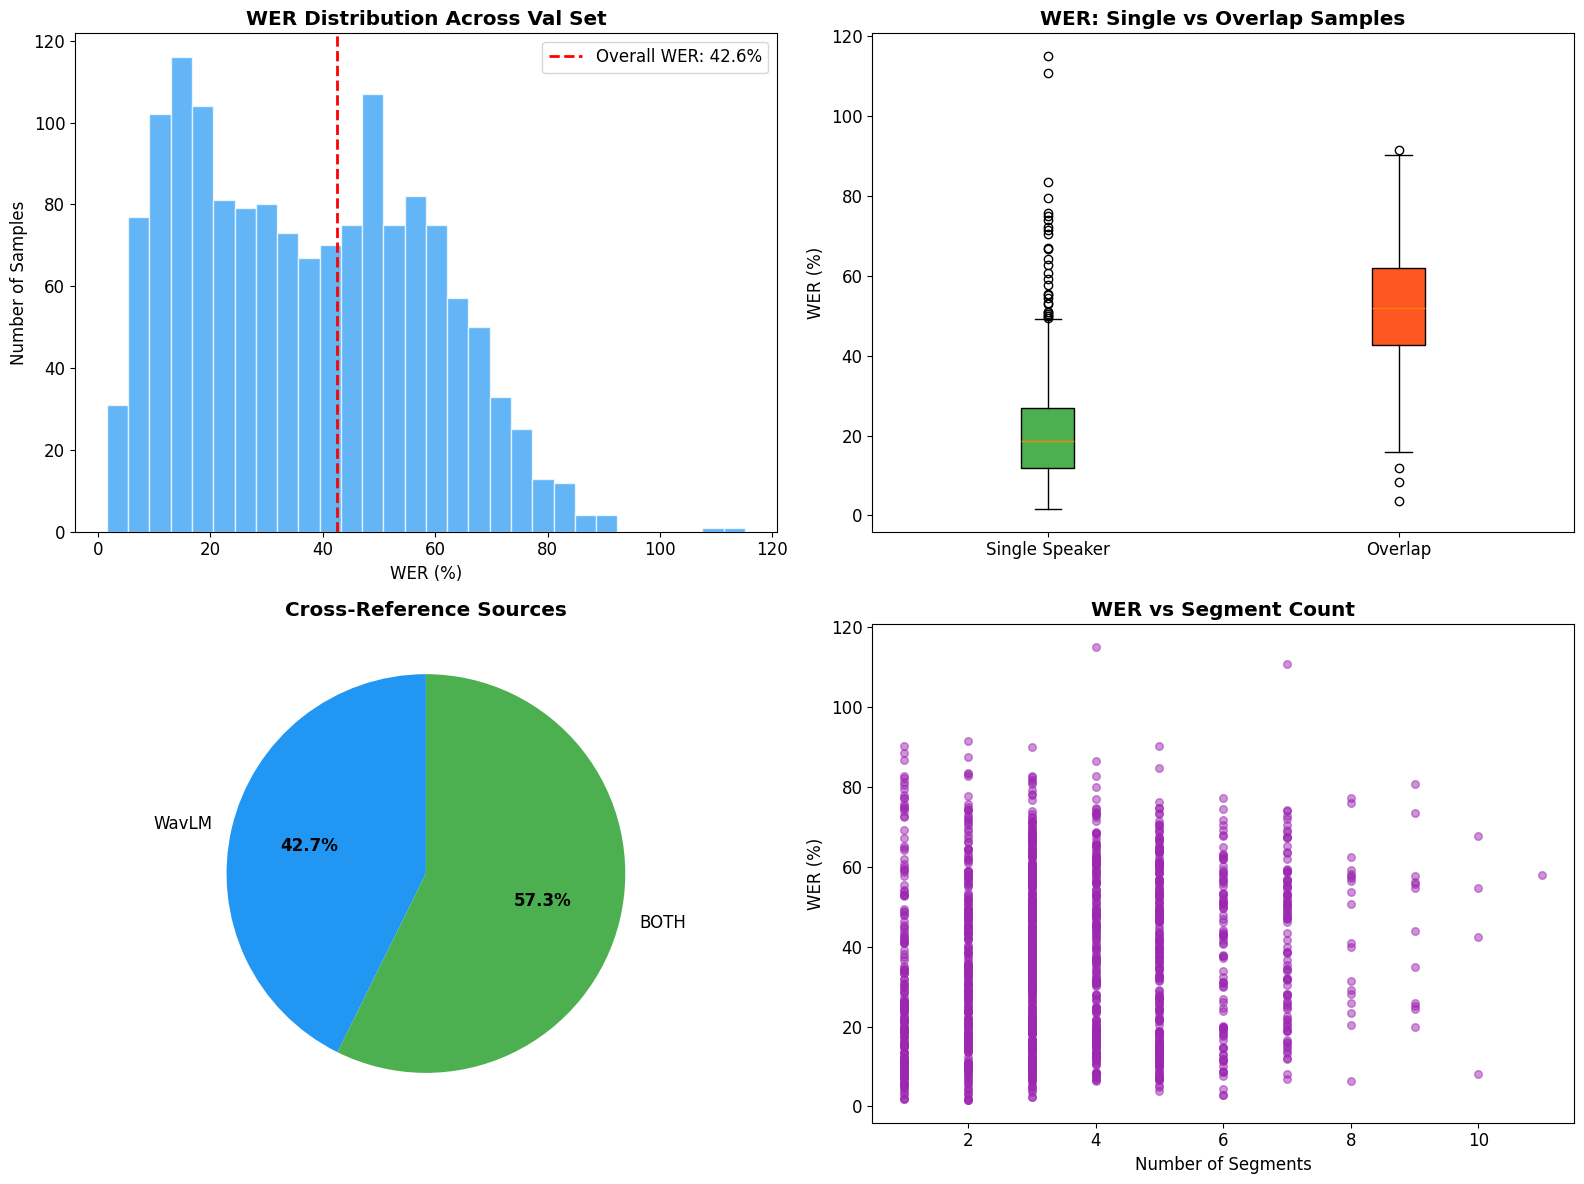

In [12]:
# Cell 10: Visualization 1 — WER Distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. WER Histogram
ax = axes[0, 0]
wers = [r['wer'] * 100 for r in results]
ax.hist(wers, bins=30, color='#2196F3', alpha=0.7, edgecolor='white')
ax.axvline(total_wer*100, color='red', linestyle='--', linewidth=2, label=f'Overall WER: {total_wer*100:.1f}%')
ax.set_xlabel('WER (%)')
ax.set_ylabel('Number of Samples')
ax.set_title('WER Distribution Across Val Set', fontweight='bold')
ax.legend()

# 2. WER: Overlap vs Single
ax = axes[0, 1]
if overlap_results and single_results:
    ov_wers = [r['wer']*100 for r in overlap_results]
    si_wers = [r['wer']*100 for r in single_results]
    bp = ax.boxplot([si_wers, ov_wers], labels=['Single Speaker', 'Overlap'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#4CAF50')
    bp['boxes'][1].set_facecolor('#FF5722')
    ax.set_ylabel('WER (%)')
    ax.set_title('WER: Single vs Overlap Samples', fontweight='bold')
else:
    ax.bar(['All'], [total_wer*100], color='#2196F3')
    ax.set_ylabel('WER (%)')
    ax.set_title('WER', fontweight='bold')

# 3. MASR Agreement Pie Chart
ax = axes[1, 0]
if all_sources:
    labels = list(all_sources.keys())
    sizes = list(all_sources.values())
    colors_pie = {'BOTH': '#4CAF50', 'WavLM': '#2196F3', 'MASR': '#FF5722'}
    pie_colors = [colors_pie.get(l, '#9E9E9E') for l in labels]
    wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%',
                                       colors=pie_colors, startangle=90)
    for t in autotexts: t.set_fontweight('bold')
    ax.set_title('Cross-Reference Sources', fontweight='bold')
else:
    ax.text(0.5, 0.5, 'No data', ha='center', va='center')

# 4. WER vs Number of Segments
ax = axes[1, 1]
n_segs = [r['n_segments'] for r in results]
wers_plot = [r['wer']*100 for r in results]
ax.scatter(n_segs, wers_plot, alpha=0.5, s=30, c='#9C27B0')
ax.set_xlabel('Number of Segments')
ax.set_ylabel('WER (%)')
ax.set_title('WER vs Segment Count', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT_DIR}/eval_wer_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


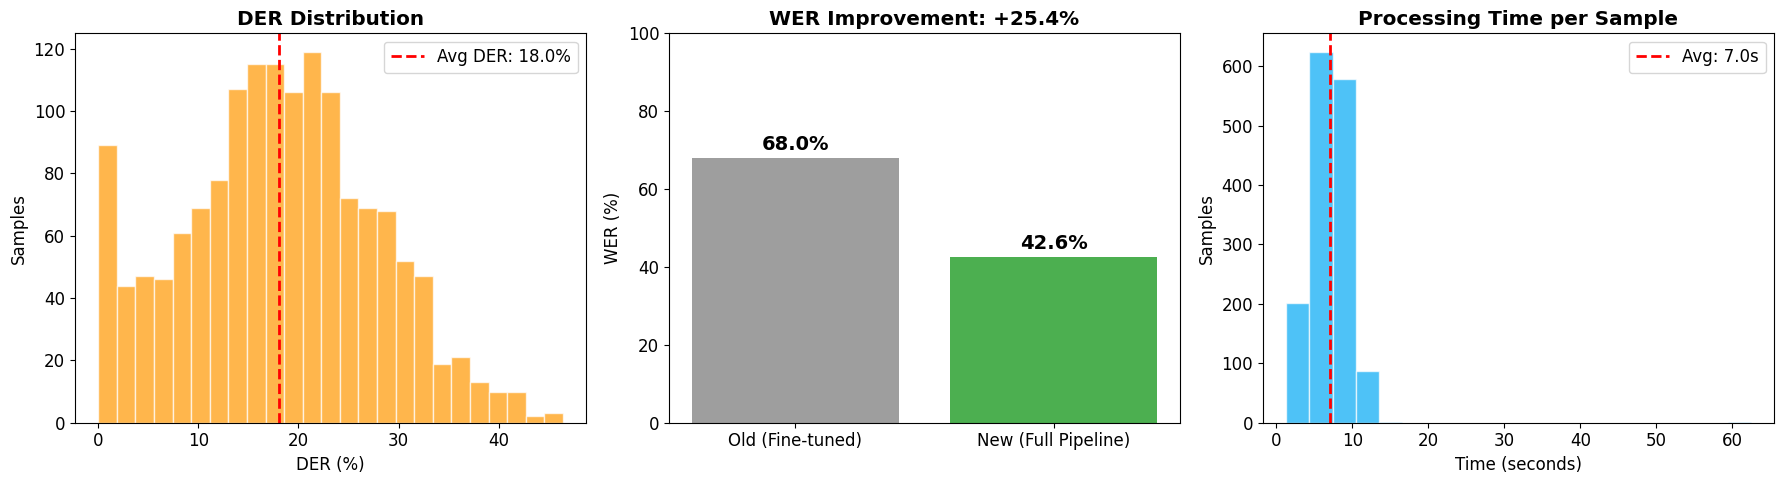

Improvement: +25.4% WER vs old method


In [13]:
# Cell 11: Visualization 2 — DER Analysis & Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. DER Distribution
ax = axes[0]
der_vals = [r['der']*100 for r in results if r['der'] > 0]
if der_vals:
    ax.hist(der_vals, bins=25, color='#FF9800', alpha=0.7, edgecolor='white')
    ax.axvline(avg_der*100, color='red', linestyle='--', linewidth=2, label=f'Avg DER: {avg_der*100:.1f}%')
    ax.set_xlabel('DER (%)')
    ax.set_ylabel('Samples')
    ax.set_title('DER Distribution', fontweight='bold')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No DER data', ha='center', va='center', fontsize=14)

# 2. WER Comparison Bar Chart (Old vs New)
ax = axes[1]
old_wer = 68.0  # From training logs
new_wer = total_wer * 100
improvement = old_wer - new_wer
bars = ax.bar(['Old (Fine-tuned)', 'New (Full Pipeline)'],
              [old_wer, new_wer],
              color=['#9E9E9E', '#4CAF50' if improvement > 0 else '#F44336'])
ax.set_ylabel('WER (%)')
ax.set_title(f'WER Improvement: {improvement:+.1f}%', fontweight='bold')
ax.set_ylim(0, 100)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

# 3. Processing Time
ax = axes[2]
times = [r['elapsed'] for r in results]
ax.hist(times, bins=20, color='#03A9F4', alpha=0.7, edgecolor='white')
ax.axvline(np.mean(times), color='red', linestyle='--', linewidth=2, label=f'Avg: {np.mean(times):.1f}s')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Samples')
ax.set_title('Processing Time per Sample', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT_DIR}/eval_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Improvement: {improvement:+.1f}% WER vs old method")


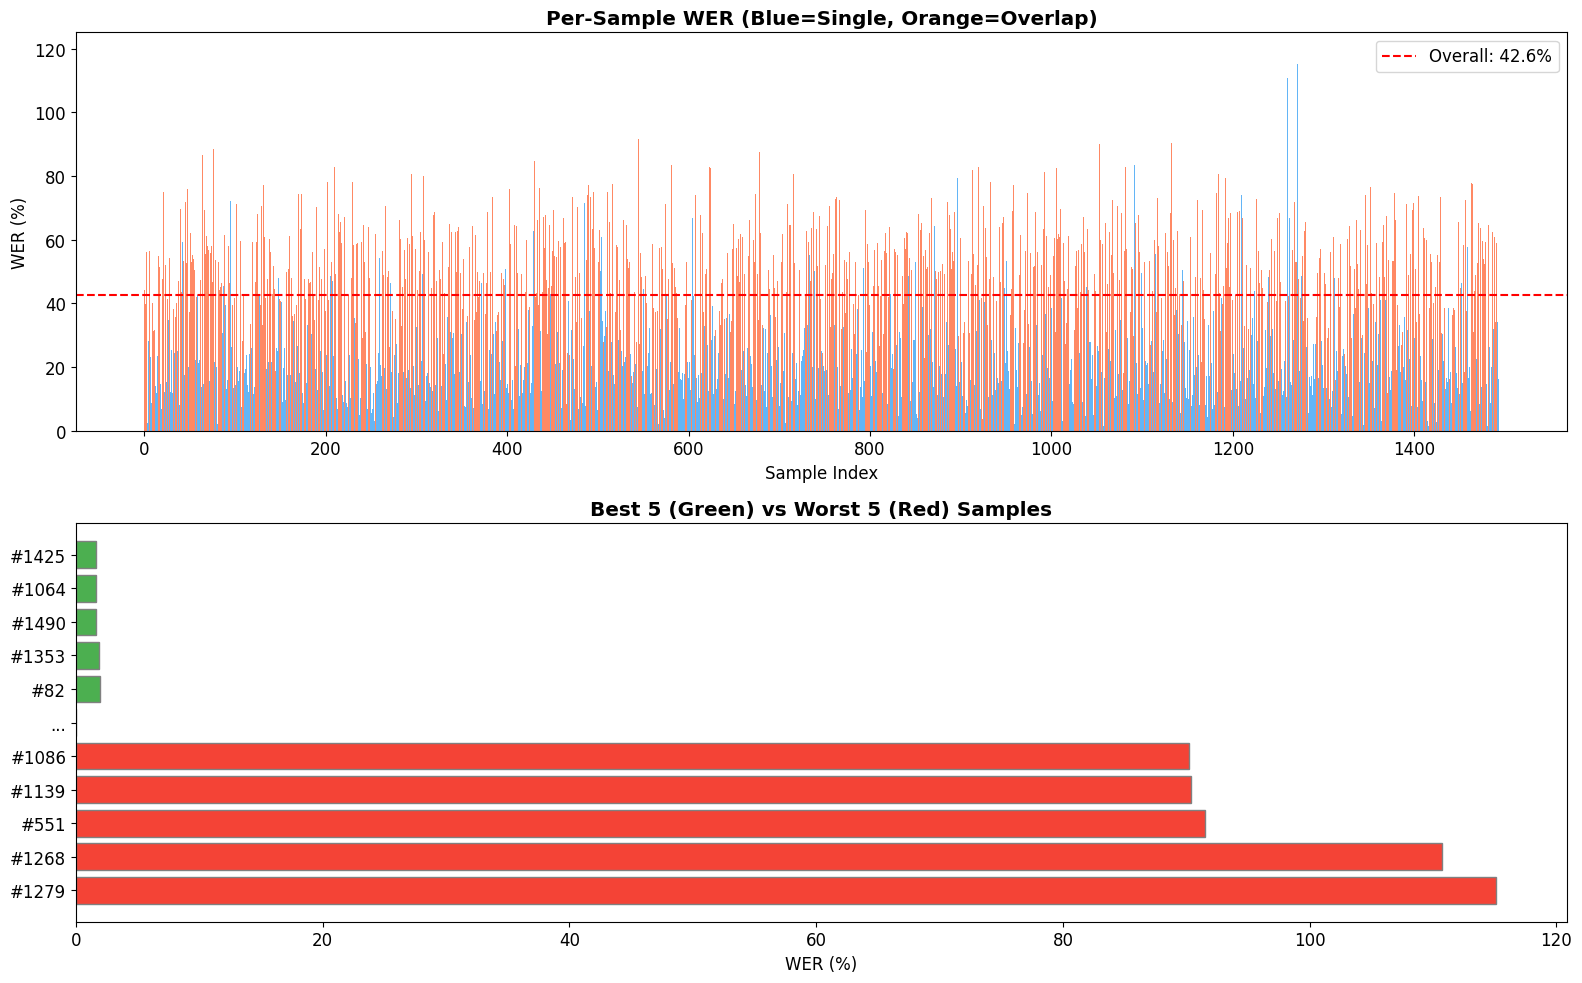

In [14]:
# Cell 12: Visualization 3 — Sample-by-Sample WER / Best & Worst
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 1. Per-sample WER
ax = axes[0]
sample_idxs = range(len(results))
sample_wers = [r['wer']*100 for r in results]
colors_bar = ['#FF5722' if r['has_overlap'] else '#2196F3' for r in results]
ax.bar(sample_idxs, sample_wers, color=colors_bar, alpha=0.7, width=1.0)
ax.axhline(total_wer*100, color='red', linestyle='--', linewidth=1.5, label=f'Overall: {total_wer*100:.1f}%')
ax.set_xlabel('Sample Index')
ax.set_ylabel('WER (%)')
ax.set_title('Per-Sample WER (Blue=Single, Orange=Overlap)', fontweight='bold')
ax.legend()
ax.set_ylim(0, min(200, max(sample_wers)+10))

# 2. Top 5 Best & Worst
ax = axes[1]
sorted_results = sorted(results, key=lambda r: r['wer'])
best5 = sorted_results[:5]
worst5 = sorted_results[-5:]

labels = []
vals = []
colors_bw = []
for r in best5:
    labels.append(f"#{r['idx']}")
    vals.append(r['wer']*100)
    colors_bw.append('#4CAF50')
labels.append('...')
vals.append(0)
colors_bw.append('white')
for r in worst5:
    labels.append(f"#{r['idx']}")
    vals.append(r['wer']*100)
    colors_bw.append('#F44336')

ax.barh(range(len(labels)), vals, color=colors_bw, edgecolor='gray')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('WER (%)')
ax.set_title('Best 5 (Green) vs Worst 5 (Red) Samples', fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f'{cfg.OUTPUT_DIR}/eval_per_sample.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Worst Samples Analysis

Xem chi tiết các samples có WER cao nhất để phân tích lỗi.


In [15]:
# Cell 13: Worst Samples Detail
sorted_by_wer = sorted(results, key=lambda r: r['wer'], reverse=True)

print("Top 10 WORST Samples:")
print("=" * 90)
for i, r in enumerate(sorted_by_wer[:10]):
    print(f"\n{'─'*90}")
    print(f"#{i+1} | Sample {r['idx']} | WER: {r['wer']*100:.1f}% | CER: {r['cer']*100:.1f}% | "
          f"Overlap: {'✓' if r['has_overlap'] else '✗'} | Segments: {r['n_segments']}")
    print(f"  REF:  {r['ref_text'][:120]}")
    print(f"  PRED: {r['pred_text'][:120]}")
    print(f"  Sources: {r['sources']}")


Top 10 WORST Samples:

──────────────────────────────────────────────────────────────────────────────────────────
#1 | Sample 1279 | WER: 115.1% | CER: 82.7% | Overlap: ✗ | Segments: 4
  REF:  spk1 ghi chép bằng sổ nhật ký điện tử thì cái thông tin nó chính xác thứ nhất thứ hai là sau khi mà hoàn thiện một cái q
  PRED: thì cái có cái mã đó đó mình sẽ ư khi mình thu thu hoạch mình sẽ giới thiệu với những cái công ty mà đến thu mua thì mìn
  Sources: {'BOTH': 2, 'WavLM': 2}

──────────────────────────────────────────────────────────────────────────────────────────
#2 | Sample 1268 | WER: 110.7% | CER: 91.5% | Overlap: ✗ | Segments: 7
  REF:  spk1 làm ruộng có cô chú giúp có cuốc ruộng có mình tự làm đến trường được thầy cô có thầy cô rất quan tâm giúp đỡ em
  PRED: có cô chú giúp cực cực cùng với điều coi mỹ đi tự làm đừng vội dụng tiền cho người dân vì bất cẩn nạn nhân đến trường là
  Sources: {'BOTH': 4, 'WavLM': 3}

────────────────────────────────────────────────────────────────────

---
## 8. Save Results


In [16]:
# Cell 14: Save Results
# Save detailed results JSON
json_path = f'{cfg.OUTPUT_DIR}/eval_results.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump({
        'pipeline': 'VAD → WavLM → Clustering → MASR Verify → Cross-Ref → ASR',
        'config': {
            'wavlm_weight': cfg.WAVLM_WEIGHT,
            'masr_weight': cfg.MASR_WEIGHT,
            'num_speakers': cfg.NUM_SPEAKERS_EXPECTED,
            'diar_window': cfg.DIAR_WINDOW_SEC,
            'diar_step': cfg.DIAR_STEP_SEC,
        },
        'metrics': {
            'total_wer': total_wer,
            'total_cer': total_cer,
            'avg_der': avg_der,
            'avg_wer_per_sample': avg_wer_per_sample,
            'num_samples': len(results),
        },
        'sources': dict(all_sources),
        'results': results
    }, f, ensure_ascii=False, indent=2)

# Save summary TXT
txt_path = f'{cfg.OUTPUT_DIR}/eval_summary.txt'
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write(f"Tell-Whisper Pipeline Evaluation on ViMD.fix Val Set\n")
    f.write(f"{'='*50}\n")
    f.write(f"Samples: {len(results)}\n")
    f.write(f"WER: {total_wer*100:.2f}%\n")
    f.write(f"CER: {total_cer*100:.2f}%\n")
    f.write(f"DER (est): {avg_der*100:.2f}%\n")
    f.write(f"Sources: {dict(all_sources)}\n")
    f.write(f"Avg time: {np.mean([r['elapsed'] for r in results]):.1f}s/sample\n")

print(f"✓ JSON: {json_path}")
print(f"✓ TXT:  {txt_path}")

# Download
from google.colab import files as dl_files
dl_files.download(json_path)
dl_files.download(txt_path)


✓ JSON: /content/drive/MyDrive/eval_results/eval_results.json
✓ TXT:  /content/drive/MyDrive/eval_results/eval_summary.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>